# What each TC radial metric is measuring

This notebook picks one strong storm from the rectified 25 km tracks
(`scratch/tc25_rectified_filt/rectified_tracks.csv`) and walks through every
metric in `scripts/tropical_cyclones/eval.md` / `tc_radial_metrics.py` one at a
time.

For each metric we take the **real** storm snapshot as the target, then build a
small **synthetic "ensemble"** that is deliberately corrupted in exactly the way
that metric is designed to catch (e.g. a displaced pressure field for the
PGF/wind mismatch metric, a smoothed field for the sharpness metric, a
wavenumber-1 wobble for the symmetry metric). Each ensemble comes from a single
corruption function with one or two physically meaningful parameters (a
stretch factor, a shift distance, a shear amplitude, ...); every member samples
that parameter from a normal distribution around a chosen mean offset, so the
ensemble spread reflects uncertainty in *how big the error is*, not generic
pixel-scale noise layered on top of a fixed field. Seeing the metric move on a
known, hand-crafted error is the point -- it's a sanity check on the metric
itself, not a model evaluation.

Storm: **track 519**, 2019-10-31 03:00 UTC, min SLP ~868 hPa near 14.8N/150.6E --
the most intense storm in the rectified-track set, so its inner-core structure
(RMW ~35-40 km) is well resolved at 25 km.

Data: `gs://vcm-ml-scratch/andrep/2025-08-12-X-SHiELD-AMIP-downscaling-3h.zarr/`
(same source as `tc_radial_eval_demo.py`). Only **one** timestep/patch is read
in this whole notebook -- everything else below operates on that single 2D
snapshot.


## Setup

In [1]:
import sys
sys.path.insert(0, "../scripts/tropical_cyclones")

import cftime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.ndimage import gaussian_filter, map_coordinates

import tc_radial_metrics as trm

plt.rcParams["figure.dpi"] = 100


In [2]:
ZARR = "gs://vcm-ml-scratch/andrep/2025-08-12-X-SHiELD-AMIP-downscaling-3h.zarr/"
TRACKS = "tc25_rectified_filt/rectified_tracks.csv"  # relative to scratch/

tracks = pd.read_csv(TRACKS, parse_dates=["time"])
track519 = tracks[tracks.track_id == 519]
row = track519.loc[track519["slp"].idxmin()]
row


track_id                                519
time                    2019-10-31 03:00:00
lat                               14.833736
lon                                 150.625
slp                                86820.15
wind                               67.45331
point_type                           interp
source_fine_track_id                   6526
dist_deg                           0.383237
Name: 27948, dtype: object

In [3]:
# Single read: an 8 deg half-width (~1600 km) box around the storm at its peak time.
HALF_DEG = 8.0

ds = xr.open_zarr(ZARR)
ts = pd.Timestamp(row.time)
t = cftime.DatetimeJulian(ts.year, ts.month, ts.day, ts.hour, ts.minute, ts.second)
sub = ds.sel(time=t, method="nearest").sel(
    latitude=slice(row.lat - HALF_DEG, row.lat + HALF_DEG),
    longitude=slice(row.lon - HALF_DEG, row.lon + HALF_DEG),
)

u = sub["eastward_wind_at_ten_meters"].values
v = sub["northward_wind_at_ten_meters"].values
wind = np.hypot(u, v)
pressure = sub["PRMSL"].values * 100.0  # mb -> Pa
precip = sub["PRATEsfc"].values * 3600.0  # kg/m2/s -> mm/hr
lats = sub["latitude"].values
lons = sub["longitude"].values

center = trm.refine_center_min_slp(pressure, lats, lons, (row.lat, row.lon))
print(f"center (lat, lon) = {center}")
print(f"min SLP = {pressure.min() / 100:.1f} hPa, max wind = {wind.max():.1f} m/s")
print(f"patch shape = {wind.shape}")


center (lat, lon) = (14.833736419677734, 150.625)
min SLP = 868.2 hPa, max wind = 67.5 m/s
patch shape = (65, 65)


In [4]:
# Pixel-space center, needed for the radial-remap corruptions below.
cy = int(np.argmin(np.abs(lats - center[0])))
cx = int(np.argmin(np.abs(lons - center[1])))
print(f"center pixel (row, col) = ({cy}, {cx})")

EDGES = trm.radial_bin_edges(dr_km=25.0, r_max_km=500.0)
R = trm.bin_centers(EDGES)


center pixel (row, col) = (32, 32)


### Helpers

Two corruption building blocks operate on the real 2D field (not the 1D
profile), so they still have to survive the azimuthal-mean/variance binning
honestly -- both are purely *radial* transforms about the true, fixed storm
center, so every corrupted field stays axisymmetric and every profile below
remains a legitimate azimuthal average:

* `radial_remap(field, stretch)` -- resamples the field around the storm center
  so that `output(r) = input(r / stretch)`. `stretch > 1` drags the storm's
  structure outward (bigger RMW, broader profile); `stretch < 1` pulls it in.
* `azimuthal_wobble(field, amp, wavenumber, phase)` -- multiplies the field by
  `1 + amp * cos(wavenumber * theta - phase)`, i.e. a shear-like asymmetry. The
  azimuthal *mean* barely changes (cos integrates to ~0 over a ring); the
  azimuthal *variance* goes up a lot -- this is what the symmetry metric is
  built to catch.

`parametric_ensemble(build_fn, **param_specs)` turns one of these corruption
functions into a small (5-member) ensemble by sampling its parameter(s) from
`Normal(mean, sigma)` per member and calling `build_fn` once per sample --
e.g. a "stretched storm" ensemble where every member has its *own* stretch
factor drawn around 1.6. The ensemble spread is therefore a physically
meaningful parameter uncertainty (how far off is the size error, the shear
amplitude...), not pixel-scale smoothing noise.


In [5]:
def radial_remap(field, stretch, center_rc=(cy, cx), order=1):
    """output(r) = input(r / stretch); stretch>1 expands, stretch<1 shrinks."""
    ny, nx = field.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    cy_, cx_ = center_rc
    src_y = cy_ + (yy - cy_) / stretch
    src_x = cx_ + (xx - cx_) / stretch
    return map_coordinates(field, [src_y, src_x], order=order, mode="nearest")


def azimuthal_wobble(field, amp, wavenumber=1, phase=0.0, center_rc=(cy, cx)):
    """Multiplicative wavenumber-k asymmetry about the storm center."""
    ny, nx = field.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    cy_, cx_ = center_rc
    theta = np.arctan2(yy - cy_, xx - cx_)
    return field * (1.0 + amp * np.cos(wavenumber * theta - phase))


def parametric_ensemble(build_fn, n_members=5, seed=0, **param_specs):
    """Ensemble built by jittering named corruption parameters around their mean.

    ``param_specs`` maps parameter name -> (mean, sigma). Each member draws its
    own value for every named parameter and calls
    ``build_fn(**sampled_params)`` to produce a 2D field, so the ensemble
    spread reflects uncertainty in the corruption itself (e.g. "how much did
    the storm stretch"), not generic per-pixel noise. Returns
    ``(members_array, samples)`` where ``samples`` maps name -> the per-member
    draws actually used.
    """
    rng = np.random.default_rng(seed)
    samples = {
        name: rng.normal(mean, sigma, n_members) for name, (mean, sigma) in param_specs.items()
    }
    members = [
        build_fn(**{name: samples[name][i] for name in param_specs})
        for i in range(n_members)
    ]
    return np.stack(members), samples


def profile_of(field, edges=EDGES, c=center):
    return trm.compute_radial_profile(field, *c, lats, lons, edges)


def plot_mean_std(ax, r, target_mean, ens_mean, scale=1.0, ylabel="", title=""):
    ax.plot(r, target_mean * scale, "k", lw=2.5, label="target")
    m = np.nanmean(ens_mean, axis=0)
    s = np.nanstd(ens_mean, axis=0)
    ax.plot(r, m * scale, "C3", lw=1.8, label="corrupted ensemble mean")
    ax.fill_between(r, (m - s) * scale, (m + s) * scale, color="C3", alpha=0.2)
    ax.set_xlabel("radius (km)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)


def plot_field_grid(panels, unit="", cmap="viridis", suptitle=""):
    """Side-by-side 2D maps (shared color scale) -- target vs. one corrupted
    *sample* (a single ensemble member, not the noiseless mean), so you can see
    what the corruption actually looks like on the storm before it gets
    collapsed into a radial profile.

    ``panels`` is an ordered ``{label: 2D field}`` dict; the first entry is
    conventionally the target.
    """
    vmin = min(np.nanmin(f) for f in panels.values())
    vmax = max(np.nanmax(f) for f in panels.values())
    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(4.3 * n, 4), squeeze=False, sharex=True, sharey=True)
    axes = axes[0]
    im = None
    for ax, (label, field) in zip(axes, panels.items()):
        im = ax.pcolormesh(lons, lats, field, vmin=vmin, vmax=vmax, cmap=cmap, shading="auto")
        ax.plot(center[1], center[0], "r+", ms=12, mew=2)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("lon")
    axes[0].set_ylabel("lat")
    if suptitle:
        fig.suptitle(suptitle)
    fig.colorbar(im, ax=axes.tolist(), label=unit, shrink=0.85)
    return fig


# The real target profiles, computed once and reused as the reference in every section below.
target_wind = profile_of(wind)
target_pressure = profile_of(pressure)
target_precip = profile_of(precip)
mask = trm.valid_wind_mask(target_wind.mean)

r_max_t, v_max_t = trm.radius_of_max_wind(target_wind.mean, R)
print(f"target R_max = {r_max_t:.0f} km, V_max = {v_max_t:.1f} m/s")


target R_max = 38 km, V_max = 53.0 m/s


## 1. Radius of Max Wind ($\Delta R_{max}$) and wind-profile MAE

**What it measures:** the storm's inner-core size and overall wind-field shape
-- is the vortex compact or broad, and does its full core-to-environment
profile match, independent of where the peak wind value itself lands.

**How it's computed:** average the 10 m wind speed azimuthally in each 25 km
ring to get $\bar V(r)$. $R_{max}$ is the radius of that profile's peak;
$\Delta R_{max} = |R_{max,sim} - R_{max,obs}|$. $MAE_{v\_radial}$ is the mean
absolute difference between the sim and obs $\bar V(r)$ curves, averaged over
every ring where the *observed* wind is at least 10 m/s (the rings that
actually belong to the storm).

**Corruption:** `radial_remap` on the wind field, with a `stretch` factor drawn
from `Normal(1.6, 0.12)` per member -- the core is dragged outward, so the
eyewall sits at a bigger radius but the peak wind speed itself barely changes.
This isolates a pure *size* error from an *intensity* error: $\Delta R_{max}$
should move a lot; the peak wind value should not.


stretch samples: [1.64 1.7  1.64 1.44 1.71]
target:    R_max=38 km, V_max=53.0 m/s
corrupted: R_max=62 km, V_max=50.0 m/s
dR_max = 25 km
MAE_v_radial = 5.08 m/s


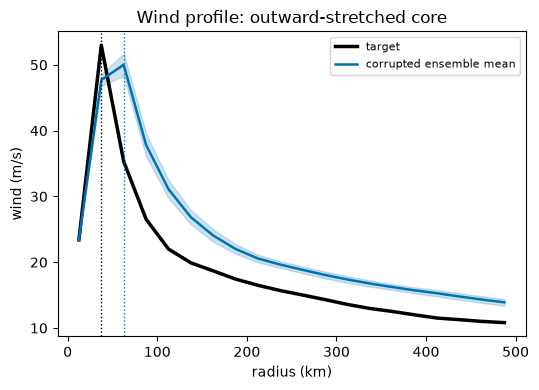

In [6]:
ens_wind_1, params_1 = parametric_ensemble(
    lambda stretch: radial_remap(wind, stretch), seed=1, stretch=(1.6, 0.12),
)
prof_wind_1 = profile_of(ens_wind_1)

r_max_c, v_max_c = trm.radius_of_max_wind(np.nanmean(prof_wind_1.mean, axis=0), R)
mae_v = trm.profile_mae(prof_wind_1.mean, target_wind.mean[None, :], mask).mean()

print(f"stretch samples: {np.round(params_1['stretch'], 2)}")
print(f"target:    R_max={r_max_t:.0f} km, V_max={v_max_t:.1f} m/s")
print(f"corrupted: R_max={r_max_c:.0f} km, V_max={v_max_c:.1f} m/s")
print(f"dR_max = {abs(r_max_c - r_max_t):.0f} km")
print(f"MAE_v_radial = {mae_v:.2f} m/s")

fig, ax = plt.subplots(figsize=(5.5, 4))
plot_mean_std(ax, R, target_wind.mean, prof_wind_1.mean, ylabel="wind (m/s)",
              title="Wind profile: outward-stretched core")
ax.axvline(r_max_t, color="k", ls=":", lw=1)
ax.axvline(r_max_c, color="C3", ls=":", lw=1)
fig.tight_layout()


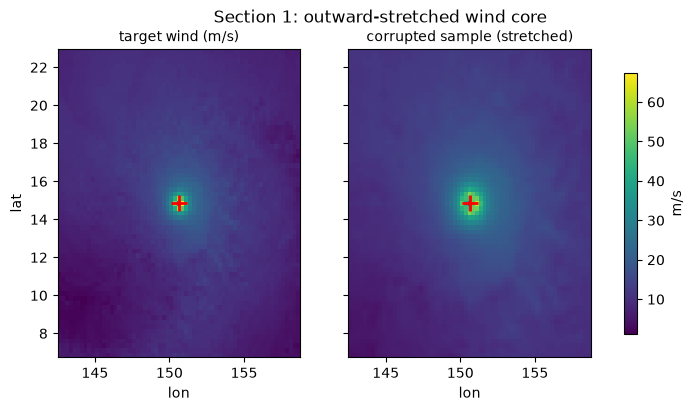

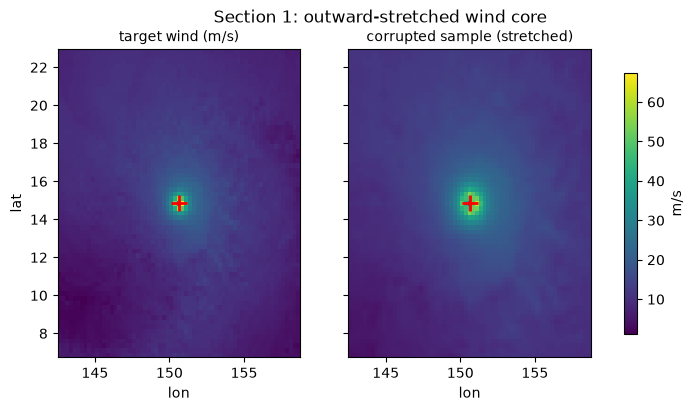

In [7]:
plot_field_grid(
    {"target wind (m/s)": wind, "corrupted sample (stretched)": ens_wind_1[0]},
    unit="m/s", suptitle="Section 1: outward-stretched wind core",
)


## 2. Wind Radii ($\Delta R_{34}, \Delta R_{50}, \Delta R_{64}$)

**What it measures:** the broadness of the *outer* wind field -- how far out
gale-force (34 kt), storm-force (50 kt), and hurricane-force (64 kt) winds
extend. This is a size/extent error at the destructive-wind scale, distinct
from $R_{max}$'s inner-core-size focus.

**How it's computed:** from the same azimuthal-mean profile $\bar V(r)$ as
section 1, find the *outermost* radius where $\bar V(r)$ crosses down through
each kt threshold (converted to m/s), linearly interpolating between the
bracketing rings. $\Delta R_{threshold} = R_{threshold,sim} -
R_{threshold,obs}$ -- signed, so you can tell whether the sim's wind field is
too broad or too narrow at each threshold, not just off by how much.

**Corruption:** uniform amplitude scaling of the wind field, `scale` drawn from
`Normal(0.8, 0.04)` per member (a storm that is structurally the same shape but
~20% weaker everywhere). This should barely move $R_{max}$ (the *shape* is
unchanged) but contracts every wind-radius threshold, especially the higher
ones (50/64 kt), since a 20% cut can push the field below a threshold entirely.


In [8]:
ens_wind_2, params_2 = parametric_ensemble(
    lambda scale: wind * scale, seed=2, scale=(0.8, 0.04),
)
prof_wind_2 = profile_of(ens_wind_2)
mean_wind_2 = np.nanmean(prof_wind_2.mean, axis=0)

target_wr = trm.wind_radii(target_wind.mean, R)
corrupt_wr = trm.wind_radii(mean_wind_2, R)

print(f"scale samples: {np.round(params_2['scale'], 2)}")
rows = []
for thr in trm.WIND_RADII_THRESHOLDS_MS:
    kt = round(thr / trm.KT_TO_MS)
    rows.append({
        "kt": kt,
        "R_target_km": target_wr[thr],
        "R_corrupted_km": corrupt_wr[thr],
        "dR_km": corrupt_wr[thr] - target_wr[thr],
    })
pd.DataFrame(rows)


scale samples: [0.81 0.78 0.78 0.7  0.87]


,kt,R_target_km,R_corrupted_km,dR_km
0,34,186.245089,111.568631,-74.676458
1,50,92.005512,70.232138,-21.773374
2,64,69.324182,53.421628,-15.902553


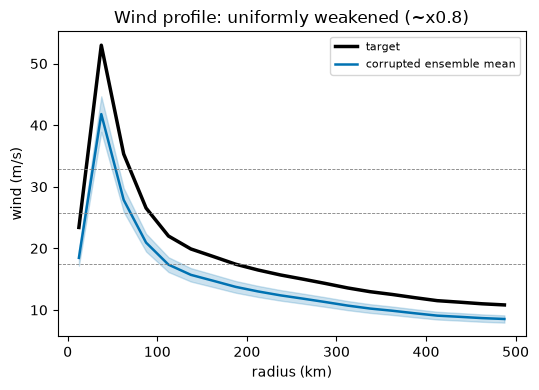

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 4))
plot_mean_std(ax, R, target_wind.mean, prof_wind_2.mean, ylabel="wind (m/s)",
              title="Wind profile: uniformly weakened (~x0.8)")
for thr in trm.WIND_RADII_THRESHOLDS_MS:
    ax.axhline(thr, color="gray", lw=0.6, ls="--")
fig.tight_layout()


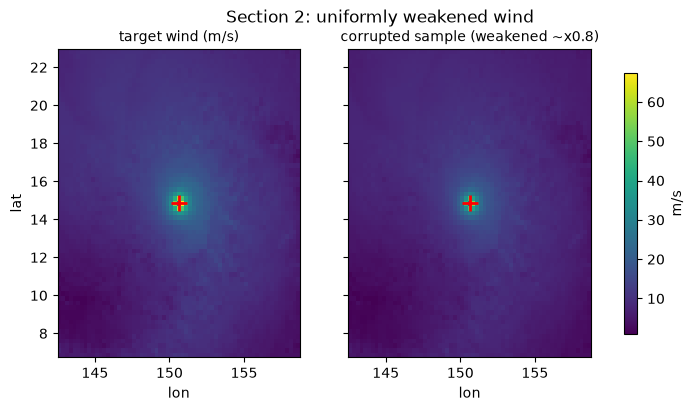

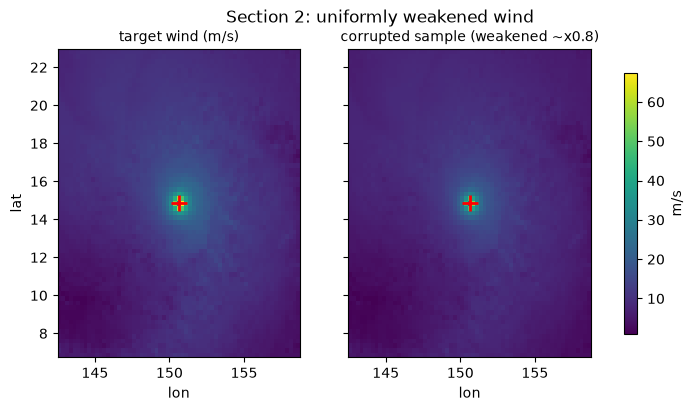

In [10]:
plot_field_grid(
    {"target wind (m/s)": wind, "corrupted sample (weakened ~x0.8)": ens_wind_2[0]},
    unit="m/s", suptitle="Section 2: uniformly weakened wind",
)


## 3. Radial Mismatch ($\Delta R_{mismatch}$): PGF vs. wind-max alignment

**What it measures:** whether the storm's mass field (pressure) and momentum
field (wind) are radially *aligned* the way gradient-wind balance predicts --
in a physically consistent storm, the radius of peak inward pressure-gradient
force should sit close to the radius of peak tangential wind. A large
mismatch flags a boundary-layer/friction-parameterization error even when
each field looks fine on its own.

**How it's computed:** compute the pressure-gradient-force profile
$PGF(r) = \frac{1}{\rho}\frac{d\bar P}{dr}$ from the azimuthal-mean SLP
profile (centered finite difference). $R_{PGFmax}$ is the radius of that
profile's peak; $R_{Vmax}$ is section 1's radius of peak wind. The signed
`radial_mismatch = R_{PGFmax} - R_{Vmax}` is computed once for sim and once
for obs; $\Delta R_{mismatch} = |mismatch_{sim} - mismatch_{obs}|$ -- so it's
a difference *of a difference*, isolating misalignment from either field's
own size error.

**Corruption:** Gaussian-blur the *pressure* field only, `sigma` (pixels) drawn
from `Normal(1.75, 0.1)` per member, while the wind field is left exactly as
observed. Blurring smooths away the sharp near-eye pressure gradient, so the
radius of maximum PGF drifts outward while $R_{Vmax}$ (from the untouched wind
field) stays put -- a pure pressure-side structural error, isolated from any
wind/size error. Unlike the wind-stretch corruptions elsewhere in this
notebook, blurring isn't a radial *remap*; but like them it involves no
center displacement, so it doesn't break the axisymmetry these profiles
assume.

(Two earlier versions of this corruption were tried and rejected: shifting the
*pressure* field off-center is a translation, not a radial error, and breaks
the very axisymmetry these profiles assume; stretching the *wind* field
instead -- moving $R_{Vmax}$ against a fixed $R_{PGFmax}$ -- turns out to be
numerically identical to $\Delta R_{max}$ whenever pressure is untouched
[$\Delta R_{mismatch} = |R_{PGFmax} - R_{Vmax,sim} - (R_{PGFmax} -
R_{Vmax,obs})| = |R_{Vmax,obs} - R_{Vmax,sim}| = \Delta R_{max}$], so it
doesn't actually demonstrate a failure mode distinct from section 1. Blurring
the *pressure* side instead keeps $\Delta R_{max} = 0$ here and isolates the
mismatch metric on its own.)


sigma samples (px): [1.95 1.49 1.79 1.69 1.7 ]
target:    R_PGFmax=12 km, R_Vmax=38 km, mismatch=-25 km
corrupted: R_PGFmax=62 km, R_Vmax=38 km, mismatch=25 km
dR_mismatch = 50 km


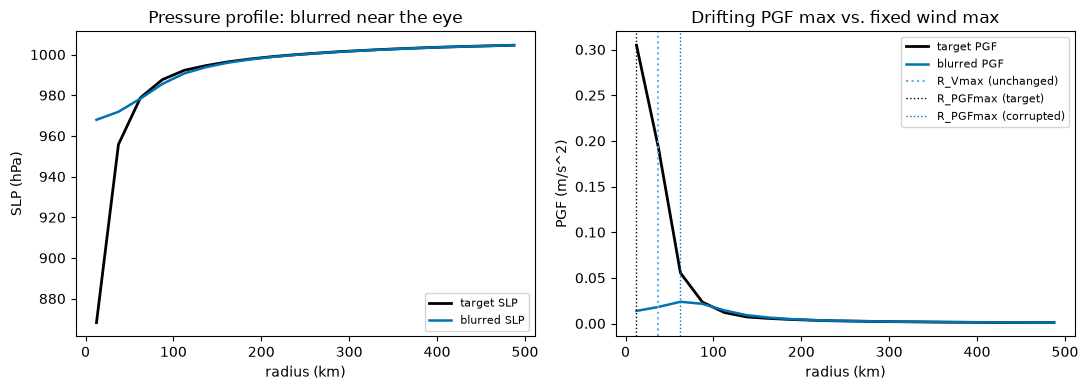

In [11]:
ens_pressure_3, params_3 = parametric_ensemble(
    lambda sigma: gaussian_filter(pressure, sigma=sigma), seed=3, sigma=(1.75, 0.1),
)
prof_pressure_3 = profile_of(ens_pressure_3)
mean_pressure_3 = np.nanmean(prof_pressure_3.mean, axis=0)

pgf_t = trm.pressure_gradient_force(target_pressure.mean, R)
pgf_c = trm.pressure_gradient_force(mean_pressure_3, R)
r_pgf_t, _ = trm.radius_of_extremum(pgf_t, R, kind="max")
r_pgf_c, _ = trm.radius_of_extremum(pgf_c, R, kind="max")

mismatch_t = r_pgf_t - r_max_t
mismatch_c = r_pgf_c - r_max_t

print(f"sigma samples (px): {np.round(params_3['sigma'], 2)}")
print(f"target:    R_PGFmax={r_pgf_t:.0f} km, R_Vmax={r_max_t:.0f} km, mismatch={mismatch_t:.0f} km")
print(f"corrupted: R_PGFmax={r_pgf_c:.0f} km, R_Vmax={r_max_t:.0f} km, mismatch={mismatch_c:.0f} km")
print(f"dR_mismatch = {abs(mismatch_c - mismatch_t):.0f} km")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(R, target_pressure.mean / 100, "k", lw=2, label="target SLP")
axes[0].plot(R, mean_pressure_3 / 100, "C3", lw=1.8, label="blurred SLP")
axes[0].set_xlabel("radius (km)"); axes[0].set_ylabel("SLP (hPa)")
axes[0].set_title("Pressure profile: blurred near the eye"); axes[0].legend(fontsize=8)

axes[1].plot(R, pgf_t, "k", lw=2, label="target PGF")
axes[1].plot(R, pgf_c, "C3", lw=1.8, label="blurred PGF")
axes[1].axvline(r_max_t, color="C0", ls=":", lw=1.5, label="R_Vmax (unchanged)")
axes[1].axvline(r_pgf_t, color="k", ls=":", lw=1, label="R_PGFmax (target)")
axes[1].axvline(r_pgf_c, color="C3", ls=":", lw=1, label="R_PGFmax (corrupted)")
axes[1].set_xlabel("radius (km)"); axes[1].set_ylabel("PGF (m/s^2)")
axes[1].set_title("Drifting PGF max vs. fixed wind max"); axes[1].legend(fontsize=8)
fig.tight_layout()


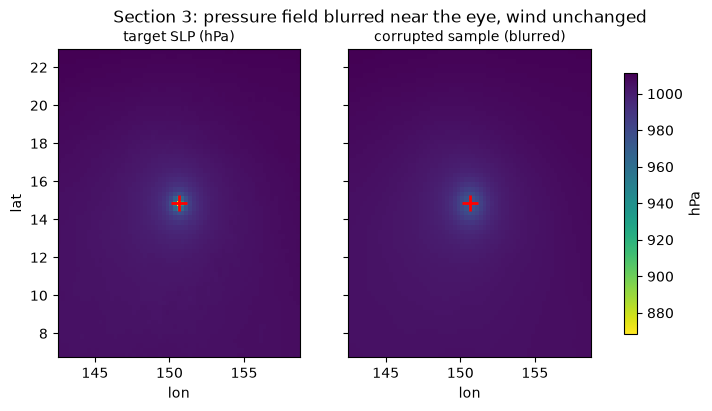

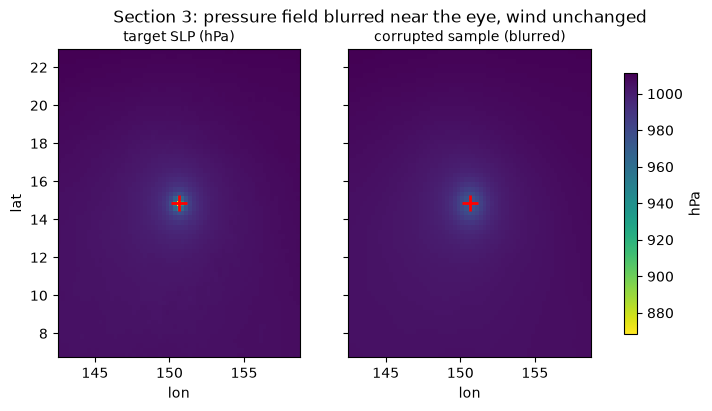

In [12]:
plot_field_grid(
    {"target SLP (hPa)": pressure / 100, "corrupted sample (blurred)": ens_pressure_3[0] / 100},
    unit="hPa", cmap="viridis_r", suptitle="Section 3: pressure field blurred near the eye, wind unchanged",
)


### A note on wind-pressure imbalance ($\Delta Imbalance$)

`eval.md` / `tc_radial_metrics.wind_pressure_imbalance` also defines a
cyclostrophic residual, $\Delta P/\rho - \int_0^{R_{outer}} V^2/r\,dr$,
scored per storm as $\Delta Imbalance = |resid_{sim} - resid_{obs}|$. Left out
of this walkthrough for now: it's a *single-storm* residual (no Coriolis term,
no storm motion/friction), so even a perfect model run against a real storm
won't be exactly zero, and that residual's baseline size varies systematically
with latitude and storm size -- conflating "model got this storm's structure
wrong" with "these are just two different storms/regimes." The pressure-wind
relationship it's gesturing at is genuinely loose and is better represented as
a **population-level** feature (a $V_{max}$ vs. $\Delta P$ scatter/distribution
across many storms, comparing sim to obs) rather than a per-storm-pair scalar
-- a good candidate for the planned multi-storm aggregate-stats pass rather
than this single-snapshot demo. The function still exists in
`tc_radial_metrics.py` if you want to compute it ad hoc.


## 4. Precipitation Morphology ($\Delta R_m, \Delta T_m, \Delta R_e$)

**What it measures:** three independent aspects of the rain shield's shape --
where the heaviest rain sits relative to the center (eyewall localization),
how intense that peak is, and how quickly rain falls off outward from it
(a tight convective core vs. a broad stratiform envelope).

**How it's computed:** from the azimuthal-mean precip-rate profile
$\bar T(r)$: $R_m$/$T_m$ are the radius/value of its maximum; $R_e$ is the
radius outward from $R_m$ where $\bar T(r)$ first drops to $T_m/e$ ($\approx$
37%). $\Delta R_m$ and $\Delta R_e$ are the absolute sim-obs difference of
each radius; $\Delta T_m$ is the *signed* sim-obs difference of the peak rate
(so you can tell too-intense from too-weak). Three separate numbers, so a
displacement error, an intensity error, and a decay-shape error don't get
averaged together into one ambiguous score.

At 25 km / 0.25 deg resolution the eyewall rain core is only about one grid
cell wide -- narrower than the 25 km ring width -- so the innermost ring's
azimuthal mean is just that single center pixel's value, and it turns out to
be *invariant* under any center-anchored radial remap (offset 0 always maps to
offset 0). A `radial_remap`, which works well for the wind field in section 1,
can't move this precip peak at all. So the three precip corruptions below use
different constructions, each with its own jittered parameter:

* **Displacement**: add an axisymmetric secondary rain-band bump (a Gaussian
  ring in true great-circle radius) whose center radius `r0` is drawn from
  `Normal(90, 8)` km, with amplitude just below the eyewall's own peak so it
  becomes the new global maximum. This moves $R_m$ a long way out while
  leaving $T_m$ almost unchanged -- a physically real pattern (a secondary
  eyewall / moat structure).
* **Amplitude**: uniform `scale` drawn from `Normal(1.6, 0.12)` -- moves $T_m$
  without moving $R_m$.
* **Broadening**: Gaussian-blur `sigma` (pixels) drawn from `Normal(3.0, 0.3)`
  -- moves the e-folding radius $R_e$ (a tight convective core becomes a wide
  stratiform-like envelope) at the cost of also denting the peak $T_m$ a bit,
  since smoothing can't avoid touching the center pixel too.


target: R_m=12 km, T_m=25.61 mm/hr, R_e=84 km


,corruption,dR_m_km,dT_m,dR_e_km
0,displaced (dR_m),0.0,1.487727e-09,24.321324
1,amplified (dT_m),0.0,1.486051e+01,0.000000
2,broadened (dR_e),0.0,-1.643516e+01,83.531108


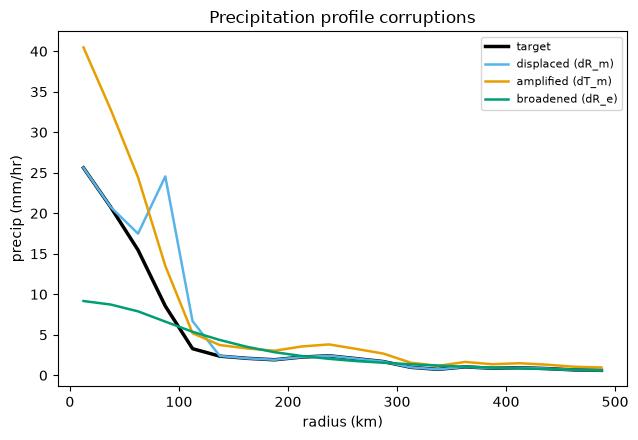

In [13]:
def gaussian_ring(dist_km, r0, width, amplitude):
    return amplitude * np.exp(-0.5 * ((dist_km - r0) / width) ** 2)


dist_km = trm.great_circle_distance_km(*center, lats, lons)
rm_t, tm_t = trm.radius_of_extremum(target_precip.mean, R, kind="max")
re_t = trm.efolding_radius(target_precip.mean, R, rm_t, tm_t)
print(f"target: R_m={rm_t:.0f} km, T_m={tm_t:.2f} mm/hr, R_e={re_t:.0f} km")

precip_corruptions = {
    "displaced (dR_m)": (
        lambda r0: precip + gaussian_ring(dist_km, r0, width=12.0, amplitude=0.85 * tm_t),
        dict(r0=(90.0, 8.0)),
    ),
    "amplified (dT_m)": (lambda scale: precip * scale, dict(scale=(1.6, 0.12))),
    "broadened (dR_e)": (
        lambda sigma: gaussian_filter(precip, sigma=sigma),
        dict(sigma=(3.0, 0.3)),
    ),
}

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(R, target_precip.mean, "k", lw=2.5, label="target")

ens_by_label = {}
rows = []
for label, (build_fn, param_specs) in precip_corruptions.items():
    ens, params = parametric_ensemble(build_fn, seed=5, **param_specs)
    ens_by_label[label] = ens
    prof = profile_of(ens)
    mean = np.nanmean(prof.mean, axis=0)
    rm_c, tm_c = trm.radius_of_extremum(mean, R, kind="max")
    re_c = trm.efolding_radius(mean, R, rm_c, tm_c)
    rows.append({
        "corruption": label,
        "dR_m_km": abs(float(rm_c) - float(rm_t)),
        "dT_m": float(tm_c) - float(tm_t),
        "dR_e_km": abs(re_c - re_t) if np.isfinite(re_c) and np.isfinite(re_t) else np.nan,
    })
    ax.plot(R, mean, lw=1.8, label=label)

ax.set_xlabel("radius (km)"); ax.set_ylabel("precip (mm/hr)")
ax.set_title("Precipitation profile corruptions"); ax.legend(fontsize=8)
fig.tight_layout()
pd.DataFrame(rows)


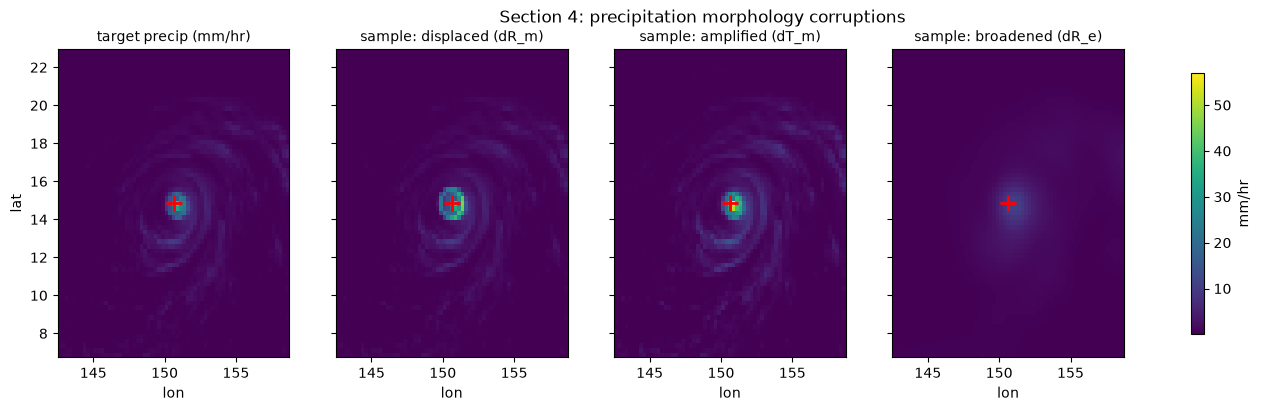

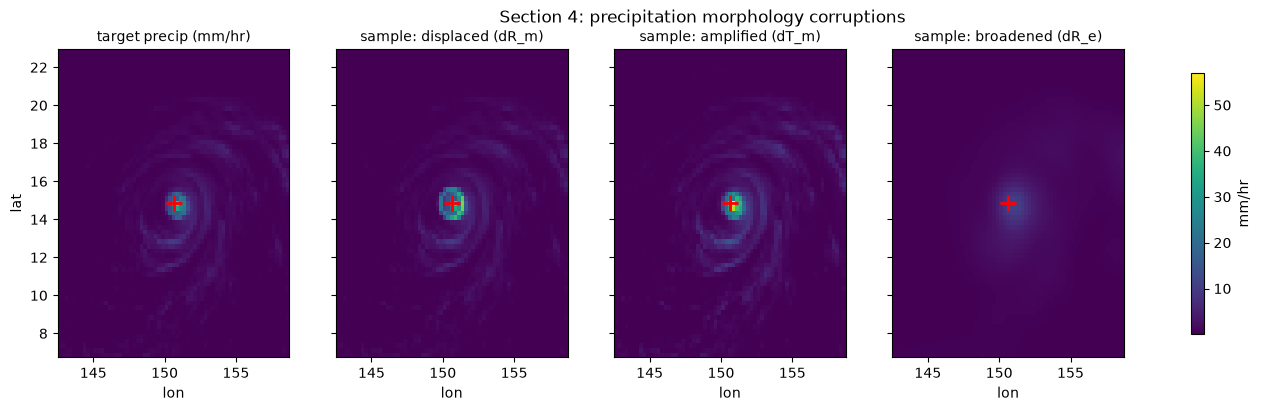

In [14]:
plot_field_grid(
    {
        "target precip (mm/hr)": precip,
        **{f"sample: {label}": ens_by_label[label][0] for label in precip_corruptions},
    },
    unit="mm/hr", suptitle="Section 4: precipitation morphology corruptions",
)


## 5. Azimuthal Symmetry ($MAE_{\sigma\_radial}$)

**What it measures:** how *asymmetric* the storm is around each ring --
shear-tilted eyewalls, one-sided rainbands, wave-1 wobbles -- a structural
feature the azimuthal-*mean* metrics in sections 1-2 are blind to by
construction (they've already averaged the asymmetry away).

**How it's computed:** at each radial ring, compute the *variance* (not the
mean) of the wind speed across all azimuths in that ring, giving a variance
profile $\sigma^2_V(r)$ alongside the usual mean profile. $MAE_{\sigma
\_radial}$ is the mean absolute difference between the sim and obs variance
profiles, over the same valid rings as section 1.

**Corruption:** `azimuthal_wobble` on the wind field, a wavenumber-1
multiplicative perturbation -- like vertical shear pushing the strongest winds
to one side of the eyewall. Both the shear `amp` (`Normal(0.3, 0.04)`) and its
`phase` (`Normal(0, 0.3 rad)`, i.e. the compass direction of the bulge) are
jittered per member, so the ensemble also captures "shear from a slightly
different direction each time," not just "shear of a slightly different
strength." The azimuthal **mean** at each radius is nearly unchanged (a
$\cos\theta$ term averages to ~0 around a ring), but the azimuthal
**variance** at each radius goes up sharply -- this is precisely the
distinction the mean-profile metrics (sections 1-2) cannot see, and
$MAE_{\sigma\_radial}$ is built to catch.


amp samples: [0.34 0.37 0.2  0.29 0.34], phase samples (rad): [0.41 0.2  0.45 0.09 0.17]
MAE_sigma_radial = 37.47 (m/s)^2
azimuthal-mean wind barely changes: max|dmean| = 6.95 m/s


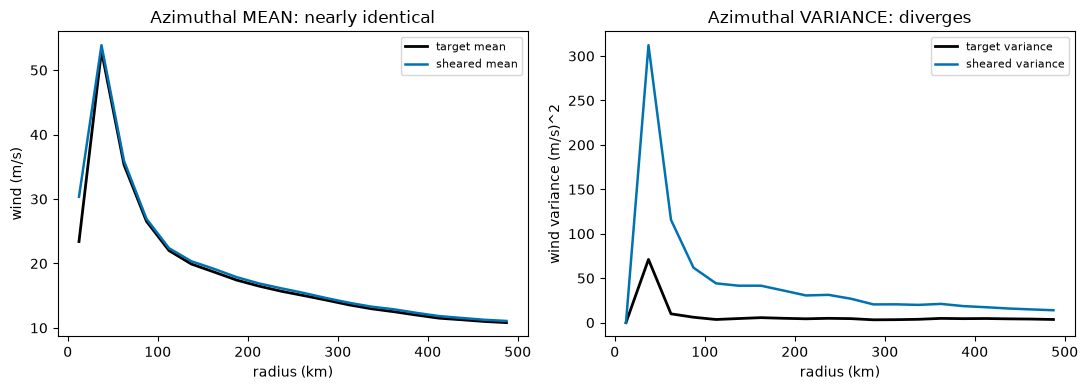

In [15]:
ens_wind_6, params_6 = parametric_ensemble(
    lambda amp, phase: azimuthal_wobble(wind, amp=amp, wavenumber=1, phase=phase),
    seed=6, amp=(0.3, 0.04), phase=(0.0, 0.3),
)
prof_wind_6 = profile_of(ens_wind_6)
mean_6 = np.nanmean(prof_wind_6.mean, axis=0)
var_6 = np.nanmean(prof_wind_6.var, axis=0)

mae_sigma = trm.profile_mae(var_6, target_wind.var, mask)
print(f"amp samples: {np.round(params_6['amp'], 2)}, phase samples (rad): {np.round(params_6['phase'], 2)}")
print(f"MAE_sigma_radial = {mae_sigma:.2f} (m/s)^2")
print("azimuthal-mean wind barely changes:",
      f"max|dmean| = {np.nanmax(np.abs(mean_6 - target_wind.mean)):.2f} m/s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(R, target_wind.mean, "k", lw=2, label="target mean")
axes[0].plot(R, mean_6, "C3", lw=1.8, label="sheared mean")
axes[0].set_title("Azimuthal MEAN: nearly identical")
axes[0].set_xlabel("radius (km)"); axes[0].set_ylabel("wind (m/s)"); axes[0].legend(fontsize=8)

axes[1].plot(R, target_wind.var, "k", lw=2, label="target variance")
axes[1].plot(R, var_6, "C3", lw=1.8, label="sheared variance")
axes[1].set_title("Azimuthal VARIANCE: diverges")
axes[1].set_xlabel("radius (km)"); axes[1].set_ylabel("wind variance (m/s)^2"); axes[1].legend(fontsize=8)
fig.tight_layout()


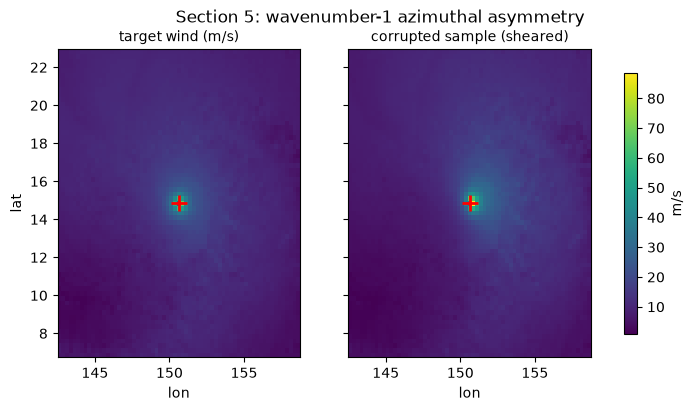

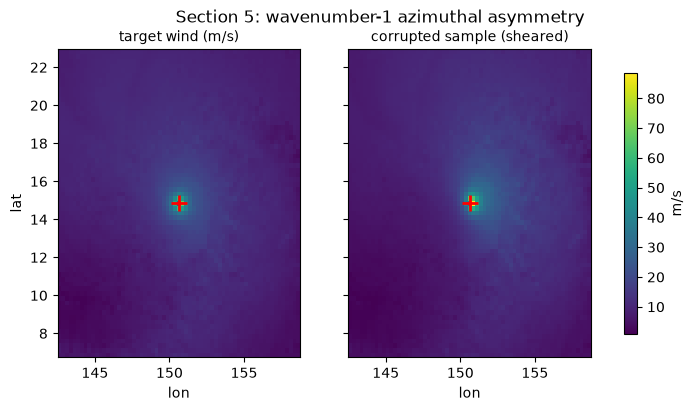

In [16]:
plot_field_grid(
    {"target wind (m/s)": wind, "corrupted sample (sheared)": ens_wind_6[0]},
    unit="m/s", suptitle="Section 5: wavenumber-1 azimuthal asymmetry",
)


## 6. Radial Gradient Sharpness ($\Delta Var_{profile}$)

**What it measures:** whether the eye-to-eyewall-to-environment transition is
too sharp/idealized or too smoothed/washed-out -- the "peakiness" of the mean
radial profile's *shape*, independent of where the peak sits ($R_{max}$,
section 1) or how strong it is ($V_{max}$).

**How it's computed:** take the variance of the 1D mean radial profile array
itself, $Var(\bar V)$ -- variance *across radii* of the profile curve, not the
azimuthal (across-ring) variance from section 5. $\Delta Var_{profile} =
Var(\bar V_{sim}) - Var(\bar V_{obs})$, signed: positive means the sim's
profile is too sharply peaked, negative means it's too diffuse.

**Corruption:** two opposite distortions of the wind field's radial shape,
both leaving $R_{max}$ roughly in place:

* **Blurred**: Gaussian smoothing whose `sigma` (pixels) is drawn from
  `Normal(4.0, 0.4)` -- an overly diffuse, washed-out eye-to-eyewall
  transition. $Var_{profile}$ should drop.
* **Sharpened**: unsharp-mask (subtract a lightly blurred copy, amplify the
  residual by a `factor` drawn from `Normal(1.5, 0.15)`) -- an overly peaked,
  idealized profile. $Var_{profile}$ should rise.


   blurred: sigma samples = [4.   4.12 3.89 3.64 3.82], Var_profile =    21.54  (target = 98.34, dVar_profile = -76.80)
 sharpened: factor samples = [1.5  1.54 1.46 1.37 1.43], Var_profile =   222.86  (target = 98.34, dVar_profile = +124.52)


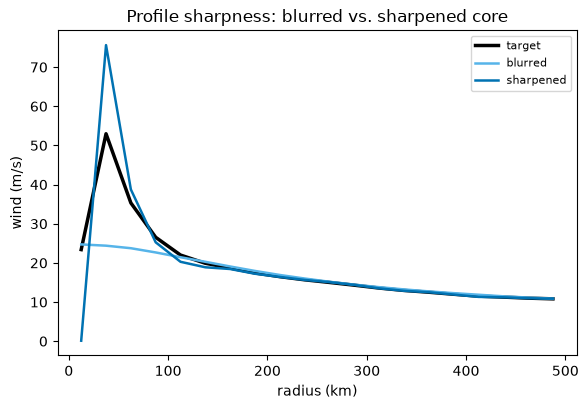

In [17]:
wind_blur_smooth = gaussian_filter(wind, sigma=1.5)  # fixed reference for the unsharp mask

sharpen_specs = {
    "blurred": (lambda sigma: gaussian_filter(wind, sigma=sigma), dict(sigma=(4.0, 0.4))),
    "sharpened": (
        lambda factor: np.clip(wind + factor * (wind - wind_blur_smooth), 0.0, None),
        dict(factor=(1.5, 0.15)),
    ),
}

var_target = trm.profile_total_variance(target_wind.mean, mask)

ens_wind_7 = {}
for label, (build_fn, param_specs) in sharpen_specs.items():
    ens, params = parametric_ensemble(build_fn, seed=7, **param_specs)
    ens_wind_7[label] = ens
    mean = np.nanmean(profile_of(ens).mean, axis=0)
    var_c = trm.profile_total_variance(mean, mask)
    pname = next(iter(param_specs))
    print(f"{label:>10s}: {pname} samples = {np.round(params[pname], 2)}, "
          f"Var_profile = {var_c:8.2f}  (target = {var_target:.2f}, "
          f"dVar_profile = {var_c - var_target:+.2f})")

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(R, target_wind.mean, "k", lw=2.5, label="target")
for label, color in zip(ens_wind_7, ["C0", "C3"]):
    ax.plot(R, np.nanmean(profile_of(ens_wind_7[label]).mean, axis=0), color, lw=1.8, label=label)
ax.set_xlabel("radius (km)"); ax.set_ylabel("wind (m/s)")
ax.set_title("Profile sharpness: blurred vs. sharpened core")
ax.legend(fontsize=8)
fig.tight_layout()


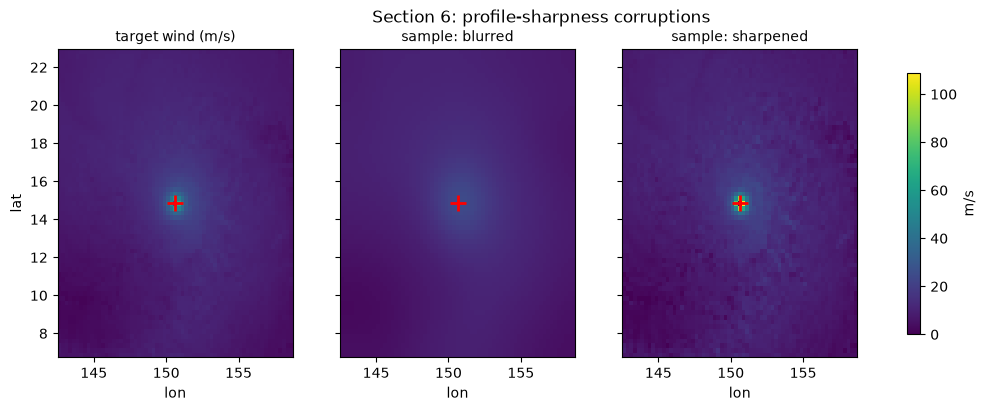

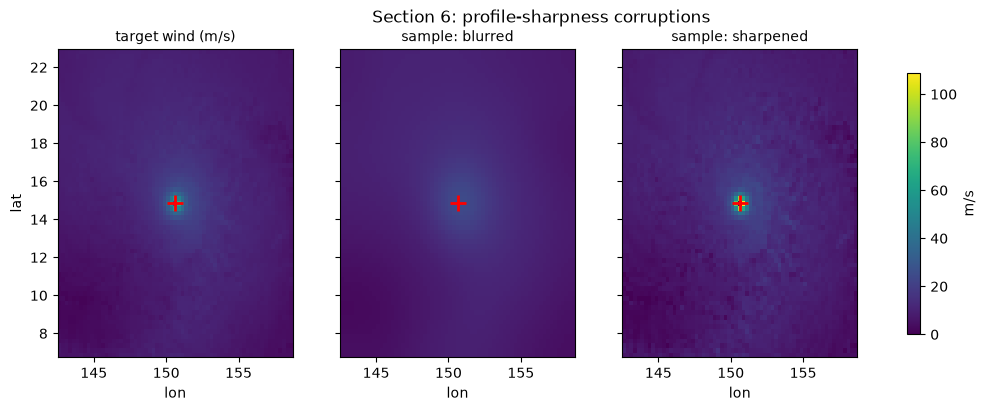

In [18]:
plot_field_grid(
    {
        "target wind (m/s)": wind,
        "sample: blurred": ens_wind_7["blurred"][0],
        "sample: sharpened": ens_wind_7["sharpened"][0],
    },
    unit="m/s", suptitle="Section 6: profile-sharpness corruptions",
)


## Summary: the full `eval.md` scorecard on each corruption

Each corruption above was built to move *one* row of the scorecard while
leaving the others close to their target value. Assembling the full scorecard
for every corrupted ensemble (using the ensembles already built in each
section above, not rebuilt here) makes that isolation explicit -- ideally each
row lights up in the column it was designed for and stays near zero elsewhere.


In [19]:
def scorecard_for(wind_ens=None, pressure_ens=None, precip_ens=None):
    sim_wind = profile_of(wind_ens) if wind_ens is not None else None
    sim_pressure = profile_of(pressure_ens) if pressure_ens is not None else None
    sim_precip = profile_of(precip_ens) if precip_ens is not None else None

    sim = trm.StormProfiles(
        r_km=R,
        wind_mean=np.nanmean(sim_wind.mean, axis=0) if sim_wind is not None else target_wind.mean,
        pressure_mean=np.nanmean(sim_pressure.mean, axis=0) if sim_pressure is not None else target_pressure.mean,
        wind_var=np.nanmean(sim_wind.var, axis=0) if sim_wind is not None else target_wind.var,
        precip_mean=np.nanmean(sim_precip.mean, axis=0) if sim_precip is not None else target_precip.mean,
    )
    obs = trm.StormProfiles(
        r_km=R, wind_mean=target_wind.mean, pressure_mean=target_pressure.mean,
        wind_var=target_wind.var, precip_mean=target_precip.mean,
    )
    return trm.scorecard(sim, obs)


scenarios = {
    "1: RMW stretch": dict(wind_ens=ens_wind_1),
    "2: wind weakened": dict(wind_ens=ens_wind_2),
    "3: pressure blurred (mismatch)": dict(pressure_ens=ens_pressure_3),
    "4: precip displaced": dict(precip_ens=ens_by_label["displaced (dR_m)"]),
    "4: precip amplified": dict(precip_ens=ens_by_label["amplified (dT_m)"]),
    "4: precip broadened": dict(precip_ens=ens_by_label["broadened (dR_e)"]),
    "5: wind sheared (asymmetric)": dict(wind_ens=ens_wind_6),
    "6: wind blurred": dict(wind_ens=ens_wind_7["blurred"]),
    "6: wind sharpened": dict(wind_ens=ens_wind_7["sharpened"]),
}

table = pd.DataFrame(
    {name: scorecard_for(**kwargs) for name, kwargs in scenarios.items()}
).T
# dImbalance is left out of this table -- see the note after section 3.
table.drop(columns="dImbalance").round(2)


,dR_max_km,MAE_v_radial,dR_34kt_km,dR_50kt_km,dR_64kt_km,dR_mismatch_km,MAE_sigma_radial,dVar_profile,dR_m_km,dT_m,dR_e_km
1: RMW stretch,25.0,5.08,121.95,55.53,36.42,25.0,4.90,9.40,0.0,0.00,0.00
2: wind weakened,0.0,3.94,-74.68,-21.77,-15.90,0.0,2.91,-37.14,0.0,0.00,0.00
3: pressure blurred (mismatch),0.0,0.00,0.00,0.00,0.00,50.0,0.00,0.00,0.0,0.00,0.00
4: precip displaced,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,24.32
4: precip amplified,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0,14.86,0.00
4: precip broadened,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0,-16.44,83.53
5: wind sheared (asymmetric),0.0,0.73,11.17,2.09,1.51,0.0,37.47,7.67,0.0,0.00,0.00
6: wind blurred,25.0,2.50,12.29,NaN,NaN,25.0,5.47,-76.80,0.0,0.00,0.00
6: wind sharpened,0.0,2.73,-4.18,-5.37,3.98,0.0,16.69,124.52,0.0,0.00,0.00


Each row should light up mainly in the column(s) it targets: row 1 in
`dR_max_km`/`MAE_v_radial`, row 2 in the `dR_*kt_km` columns, row 3 in
`dR_mismatch_km`, row 4 in the precip columns, row 5 in `MAE_sigma_radial`
(with `dR_max_km`/`MAE_v_radial` staying small, since the azimuthal mean is
nearly unchanged), and row 6 in `dVar_profile` (opposite signs for blurred
vs. sharpened).
